<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_46_pca_demo/Lecture_46_Pca_Demo_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Imports data from Kaggle and loads it into a pandas DataFrame.
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

# Download the competition data and get the path to the downloaded files
digit_recognizer_root = kagglehub.competition_download('digit-recognizer')

print('Data source import complete.')
print(f"Competition data downloaded to: {digit_recognizer_root}") # Print the download path for verification

# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.h. pd.read_csv)
import os

# Construct the full path to train.csv using the downloaded data root
train_csv_path = os.path.join(digit_recognizer_root, 'train.csv')

# Verify if the file exists at the constructed path
if not os.path.exists(train_csv_path):
    print(f"Error: train.csv not found at {train_csv_path}")
else:
    print(f"Found train.csv at: {train_csv_path}")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# You can still list files in the original input directory if needed,
# but the downloaded data might be elsewhere.
print("\nListing files in /kaggle/input/ (if available):")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Read the CSV using the correct path from the download
df = pd.read_csv(train_csv_path)

In [ ]:
# Example of reading data from the original Kaggle input directory (commented out).
# df = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

In [ ]:
# Displays the first 5 rows of the DataFrame.
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Displays the shape of the DataFrame (number of rows and columns).
df.shape

(42000, 785)

In [ ]:
# Displays a random sample row from the DataFrame.
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
37338,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Imports the matplotlib library for plotting.
import matplotlib.pyplot as plt

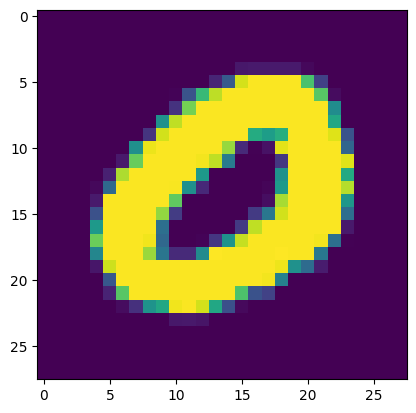

In [ ]:
# Displays an image of a digit from the DataFrame.
plt.imshow(df.iloc[20537,1:].values.reshape(28,28))

In [ ]:
# Separates features (x) and labels (y) from the DataFrame.
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [ ]:
# Splits the data into training and testing sets.
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
# Displays the shape of the training features.
x_train.shape

(33600, 784)

In [ ]:
# Imports the KNeighborsClassifier from scikit-learn.
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Initializes a KNeighborsClassifier model.
knn = KNeighborsClassifier()

In [ ]:
# Trains the KNeighborsClassifier model on the training data.
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
# Predicts labels for the test set and measures the time taken.
import time
start = time.time()
y_pred = knn.predict(x_test)
print(time.time()- start)

20.777223110198975


In [ ]:
# Imports the accuracy_score metric from scikit-learn and calculates the accuracy of the model on the test set.
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

In [ ]:
# Imports the StandardScaler from scikit-learn.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
# Scales the training and testing data using StandardScaler.
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
# Imports PCA from scikit-learn and initializes it with 200 components.
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components =200)

In [ ]:
# Applies PCA to the scaled training and testing data.
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [ ]:
# Displays the shape of the transformed training data.
x_train_trf.shape

(33600, 200)

In [ ]:
# Initializes a new KNeighborsClassifier model.
knn = KNeighborsClassifier()

In [ ]:
# Trains the KNeighborsClassifier model on the PCA-transformed training data.
knn.fit(x_train_trf,y_train)

KNeighborsClassifier()

In [ ]:
# Predicts labels for the PCA-transformed test set.
y_pred = knn.predict(x_test_trf)

In [ ]:
# Calculates the accuracy of the model on the PCA-transformed test set.
accuracy_score(y_test,y_pred)

0.9507142857142857

In [ ]:
# Loops through different numbers of PCA components and prints the accuracy for each.
for i in range(1,20):

    pca = PCA(n_components =i)

    x_train_trf = pca.fit_transform(x_train)

    x_test_trf = pca.transform(x_test)

    knn = KNeighborsClassifier()

    knn.fit(x_train_trf,y_train)

    y_pred = knn.predict(x_test_trf)



    print(accuracy_score(y_test,y_pred))

0.2580952380952381
0.3236904761904762
0.5104761904761905
0.6663095238095238
0.7378571428571429
0.8227380952380953
0.8436904761904762
0.8721428571428571
0.886547619047619
0.9055952380952381
0.9116666666666666
0.9184523809523809
0.9276190476190476
0.9351190476190476
0.9384523809523809
0.9379761904761905
0.9407142857142857
0.94
0.9425


In [ ]:
# Transforms the data to a 2D coordinate system using PCA.

pca = PCA(n_components=2)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [ ]:
# Displays the transformed training data (in 2D).
x_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]])

In [ ]:
# Transforms the data to a 2D coordinate system and visualizes it using Plotly.

pca = PCA(n_components=2)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

import plotly.express as px
import numpy as np

fig = px.scatter(x= x_train_trf[:, 0],
                 y=x_train_trf[:, 1],
                 color=y_train.astype(str),
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [ ]:
# Transforms the data to a 3D coordinate system using PCA.

pca = PCA(n_components=3)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [ ]:
# Displays the transformed training data (in 3D).
x_train_trf

array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]])

In [ ]:
# Visualizes the 3D transformed data using Plotly.
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=x_train_trf[:,0], y=x_train_trf[:,1], z=x_train_trf[:,2],
                    color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20)
)
fig.show()

In [ ]:
# Displays the explained variance of each component (eigenvalues).
pca.explained_variance_
# Eigen values

array([40.67111198, 29.17023401, 26.74459621])

In [ ]:
# Displays the shape of the principal components.
pca.components_.shape

(3, 784)

In [ ]:
# Displays the explained variance ratio of each component.
pca.explained_variance_ratio_

array([0.05785192, 0.0414927 , 0.03804239])

In [ ]:
# Transforms the data using PCA with all components.
# transforming to a 2D coordinate system
pca = PCA(n_components=None)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [ ]:
# Displays the shape of the explained variance.
pca.explained_variance_.shape

(784,)

In [ ]:
# Displays the shape of the principal components when using all components.
pca.components_.shape

(784, 784)

In [ ]:
# Calculates and displays the cumulative explained variance ratio.
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

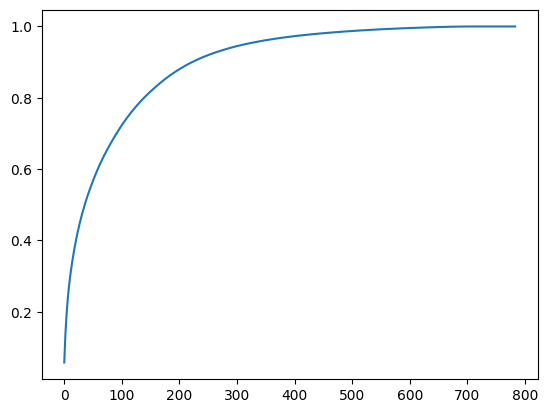

In [ ]:
# Plots the cumulative explained variance ratio.
plt.plot(np.cumsum(pca.explained_variance_ratio_))